# 🇮🇩 Analisis Sentimen Tweet Calon Presiden Indonesia 2024
**Model:** Fine-tuned IndoBERT + Classification Head

**Strategi Anti-Overfitting:**
- Partial freezing (hanya 4 layer teratas BERT yang dilatih)
- Label smoothing
- Dropout 0.5
- Early stopping by val_loss

**Strategi Anti-Imbalance:**
- WeightedRandomSampler
- Weighted CrossEntropy Loss
- Threshold tuning per epoch

> **Catatan Data:**
> - Data *original* → Teks bahasa Indonesia (tidak ada label)
> - Data *labeled* → Label sentimen (teks dalam bahasa Inggris, tidak dipakai untuk teks)
> - **Anies Baswedan:** Jumlah data tidak seimbang → merge by `Date + Created + Tweet Count`
> - **Ganjar & Prabowo:** Jumlah data seimbang → label ditempel langsung

## ⚙️ Cell 1: Install Library

In [32]:
%pip install -q kagglehub transformers torch scikit-learn seaborn tqdm

## 📦 Cell 2: Import & Konfigurasi Global

In [33]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

# --- Konfigurasi Global ---
SEED        = 42
MAX_LEN     = 128
BATCH_SIZE  = 32
EPOCHS      = 8         # Ditingkatkan menjadi 8 untuk pelatihan lebih lama
LR          = 2e-5       # LR disesuaikan untuk full fine-tuning
DROPOUT     = 0.5        # Dropout tinggi untuk regularisasi
PATIENCE    = 3          # Early stopping — ditingkatkan menjadi 3
MODEL_NAME  = 'indobenchmark/indobert-base-p1'
MODEL_PATH  = '/content/best_indobert_model.pt'

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Hardware aktif: {device.type.upper()}')

✅ Hardware aktif: CUDA


## 📂 Cell 3: Pemuatan & Preprocessing Data

In [34]:
import kagglehub

print('Mengunduh dataset dari Kaggle...')
base_path = kagglehub.dataset_download('jocelyndumlao/indonesia-presidential-candidates-dataset-2024')
print(f'✅ Dataset tersedia di: {base_path}')


# --- Helper Functions ---
def find_folder(base_dir: str, target_name: str) -> str:
    for root, dirs, _ in os.walk(base_dir):
        if target_name in dirs:
            return os.path.join(root, target_name)
    raise FileNotFoundError(f"Folder '{target_name}' tidak ditemukan di {base_dir}")


def clean_tweet(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def normalize_join_cols(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    df = df.copy()
    for col in cols:
        df[col] = (
            df[col].astype(str)
                   .str.strip()
                   .str.replace(r'\+\d{2}:\d{2}$', '', regex=True)
                   .str.strip()
        )
    return df


# --- Load Folder Paths ---
original_data_path = find_folder(base_path, 'original data')
labeled_data_path  = find_folder(base_path, 'labeled data')
print(f'📁 Original data : {original_data_path}')
print(f'📁 Labeled data  : {labeled_data_path}')


# --- Proses Data per Kandidat ---
CANDIDATES = ['Anies Baswedan.csv', 'Ganjar Pranowo.csv', 'Prabowo Subianto.csv']
JOIN_KEYS  = ['Date', 'Created', 'Tweet Count']
df_list    = []

print('\nMemproses data per kandidat...\n')
for candidate in CANDIDATES:
    file_ori   = os.path.join(original_data_path, candidate)
    file_label = os.path.join(labeled_data_path,  candidate)

    df_ori   = pd.read_csv(file_ori,   encoding='latin-1', on_bad_lines='skip')
    df_label = pd.read_csv(file_label, encoding='latin-1', on_bad_lines='skip')

    # Bersihkan BOM dan whitespace pada nama kolom
    df_ori.columns   = [c.encode('utf-8').decode('utf-8-sig').strip() for c in df_ori.columns]
    df_label.columns = [c.encode('utf-8').decode('utf-8-sig').strip() for c in df_label.columns]

    # Deteksi kolom teks bahasa Indonesia (dari original)
    col_text = next(
        (c for c in df_ori.columns if c.lower() in ['tweet', 'text']),
        df_ori.columns[-1]
    )

    # ============================================================
    # ANIES: Jumlah data tidak seimbang antara original & labeled
    # → Merge berdasarkan Date + Created + Tweet Count
    #   (menghindari masalah User ID yang diformat float oleh Excel)
    # ============================================================
    if candidate == 'Anies Baswedan.csv':
        print(f'🔄 {candidate} → Metode MERGE by Date + Created + Tweet Count')
        df_ori   = normalize_join_cols(df_ori,   JOIN_KEYS)
        df_label = normalize_join_cols(df_label, JOIN_KEYS)
        df_ori['_key']   = df_ori[JOIN_KEYS].agg('|'.join, axis=1)
        df_label['_key'] = df_label[JOIN_KEYS].agg('|'.join, axis=1)
        print(f'   Original  : {len(df_ori)} baris | Unique key: {df_ori["_key"].nunique()}')
        print(f'   Labeled   : {len(df_label)} baris | Unique key: {df_label["_key"].nunique()}')
        df_merged = pd.merge(
            df_ori,
            df_label[['_key', 'label']],
            on='_key', how='inner'
        ).drop(columns=['_key'])
        df_merged = df_merged.drop_duplicates(subset=JOIN_KEYS).reset_index(drop=True)
        print(f'   ✅ Hasil merge: {len(df_merged)} baris\n')

    # ============================================================
    # GANJAR & PRABOWO: Data seimbang → tempel label langsung
    # ============================================================
    else:
        print(f'⏩ {candidate} → Metode DIRECT LABEL')
        panjang_min        = min(len(df_ori), len(df_label))
        df_merged          = df_ori.iloc[:panjang_min].copy()
        df_merged['label'] = df_label['label'].iloc[:panjang_min].values
        print(f'   ✅ Label ditempel: {len(df_merged)} baris\n')

    df_merged['clean_text'] = df_merged[col_text].apply(clean_tweet)
    df_merged['aktor']      = candidate.replace('.csv', '')
    df_bersih = df_merged[df_merged['clean_text'] != ''][['aktor', 'clean_text', 'label']]
    df_list.append(df_bersih)


# --- Finalisasi Dataset ---
df_all = pd.concat(df_list, ignore_index=True)

n_before = len(df_all)
df_all   = df_all.drop_duplicates(subset=['clean_text']).reset_index(drop=True)
print(f'🗑️  Hapus {n_before - len(df_all)} duplikat teks')

df_all = df_all[df_all['clean_text'].str.split().str.len() >= 3].reset_index(drop=True)
df_all['target'] = df_all['label'].map({'Positive': 1, 'Negative': 0})
df_all = df_all.dropna(subset=['target']).reset_index(drop=True)
df_all = df_all.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'\n✅ Total data siap: {len(df_all)} baris')
print('\nDistribusi kelas:')
print(df_all['target'].value_counts().rename({1: 'Positive', 0: 'Negative'}))
print('\nDistribusi per kandidat:')
print(df_all.groupby(['aktor', 'label']).size().unstack(fill_value=0))

Mengunduh dataset dari Kaggle...
Using Colab cache for faster access to the 'indonesia-presidential-candidates-dataset-2024' dataset.
✅ Dataset tersedia di: /kaggle/input/indonesia-presidential-candidates-dataset-2024
📁 Original data : /kaggle/input/indonesia-presidential-candidates-dataset-2024/Indonesia Presidential Candidates Dataset, 2024/original data
📁 Labeled data  : /kaggle/input/indonesia-presidential-candidates-dataset-2024/Indonesia Presidential Candidates Dataset, 2024/labeled data

Memproses data per kandidat...

🔄 Anies Baswedan.csv → Metode MERGE by Date + Created + Tweet Count
   Original  : 10000 baris | Unique key: 9998
   Labeled   : 10000 baris | Unique key: 9998
   ✅ Hasil merge: 9998 baris

⏩ Ganjar Pranowo.csv → Metode DIRECT LABEL
   ✅ Label ditempel: 10000 baris

⏩ Prabowo Subianto.csv → Metode DIRECT LABEL
   ✅ Label ditempel: 10000 baris

🗑️  Hapus 7186 duplikat teks

✅ Total data siap: 22406 baris

Distribusi kelas:
target
Positive    16381
Negative     6025

## 🗂️ Cell 4: Dataset & DataLoader

In [35]:
# Instal library imbalanced-learn
%pip install -q imbalanced-learn

In [36]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class TweetDataset(Dataset):
    def __init__(self, texts: list, labels: list, tokenizer, max_len: int):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


# Split data — stratify menjaga proporsi kelas di train & test
X_train, X_test, y_train, y_test = train_test_split(
    df_all['clean_text'].tolist(),
    df_all['target'].astype(int).tolist(),
    test_size=0.2,
    random_state=SEED,
    stratify=df_all['target']
)

train_dataset = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
test_dataset  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)

# WeightedRandomSampler — setiap batch punya distribusi kelas seimbang
# lebih efektif dari weighted loss saja untuk data imbalance
class_counts_train = np.bincount(y_train)
sample_weights     = [1.0 / class_counts_train[label] for label in y_train]
sampler            = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

print(f'✅ Train : {len(train_dataset)} sampel ({len(train_loader)} batch)')
print(f'✅ Test  : {len(test_dataset)} sampel ({len(test_loader)} batch)')
print(f'\nDistribusi kelas train:')
print(f'   Negatif : {class_counts_train[0]}')
print(f'   Positif : {class_counts_train[1]}')

✅ Train : 17924 sampel (561 batch)
✅ Test  : 4482 sampel (141 batch)

Distribusi kelas train:
   Negatif : 4820
   Positif : 13104


## 🧠 Cell 5: Arsitektur Model — Fine-tuned IndoBERT + Classification Head

In [37]:
class IndoBERTClassifier(nn.Module):
    """
    Fine-tuned IndoBERT dengan Classification Head untuk sentimen biner.
    Semua layer IndoBERT akan dilatih (full fine-tuning).
    """
    def __init__(self, model_name: str, dropout: float = 0.5):
        super(IndoBERTClassifier, self).__init__()
        self.bert   = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size  # 768 untuk base

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 2)  # 2 kelas: Negative=0, Positive=1
        )

    def forward(self, input_ids, attention_mask):
        outputs    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        return self.classifier(cls_output)


model = IndoBERTClassifier(MODEL_NAME, DROPOUT)

# ── Full Fine-tuning ──────────────────────────────────────────
# Semua parameter BERT akan dilatih (tidak ada freezing)
# ─────────────────────────────────────────────────────────────

model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f'✅ Model siap dengan full fine-tuning')
print(f'   Total parameter    : {total_params:,}')
print(f'   Trainable parameter: {trainable_params:,}')
print(f'   Frozen parameter   : {frozen_params:,}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model siap dengan full fine-tuning
   Total parameter    : 124,655,298
   Trainable parameter: 124,655,298
   Frozen parameter   : 0


In [38]:
# Differential learning rate:
# BERT layers (yang tidak di-freeze) pakai LR kecil
# Classifier head pakai LR lebih besar karena diinisialisasi dari nol
optimizer = torch.optim.AdamW([
    {'params': model.bert.parameters(),       'lr': LR,      'weight_decay': 0.05},
    {'params': model.classifier.parameters(), 'lr': LR * 10, 'weight_decay': 0.05}
])

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)  # 10% epoch pertama untuk warmup LR

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Weighted CrossEntropy + Label Smoothing
# label_smoothing=0.1 mencegah model terlalu confident pada training data
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion     = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

print(f'✅ Optimizer : AdamW | BERT lr={LR} | Classifier lr={LR * 10}')
print(f'✅ Scheduler : Linear Warmup ({warmup_steps} warmup / {total_steps} total steps)')
print(f'✅ Loss      : CrossEntropyLoss (weighted + label_smoothing=0.1)')
print(f'✅ Class weights → Negatif: {class_weights[0]:.4f} | Positif: {class_weights[1]:.4f}')

✅ Optimizer : AdamW | BERT lr=2e-05 | Classifier lr=0.0002
✅ Scheduler : Linear Warmup (448 warmup / 4488 total steps)
✅ Loss      : CrossEntropyLoss (weighted + label_smoothing=0.1)
✅ Class weights → Negatif: 1.8593 | Positif: 0.6839


## 🏋️ Cell 7: Training Loop

In [39]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for batch in tqdm(loader, desc='Training', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()

        # Gradient clipping — cegah exploding gradient saat fine-tuning
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        preds          = torch.argmax(logits, dim=1)
        total_loss    += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluasi ', leave=False):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            logits = model(input_ids, attention_mask)
            loss   = criterion(logits, labels)
            probs  = torch.softmax(logits, dim=1)[:, 1]  # probabilitas kelas Positif
            preds  = torch.argmax(logits, dim=1)

            total_loss    += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return total_loss / total_samples, total_correct / total_samples, all_preds, all_labels, all_probs


def find_best_threshold(probs: list, labels: list) -> tuple:
    """Cari threshold optimal berdasarkan F1 macro tertinggi."""
    thresholds  = np.arange(0.3, 0.71, 0.05)
    best_thresh = 0.5
    best_f1     = 0.0
    for t in thresholds:
        preds = (np.array(probs) >= t).astype(int)
        f1    = f1_score(labels, preds, average='macro')
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t
    return best_thresh, best_f1


# --- Training ---
print(f'Mulai training {EPOCHS} epoch...\n')

best_val_loss    = float('inf')
best_threshold   = 0.5
patience_counter = 0
history          = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    print(f'Epoch {epoch}/{EPOCHS}')

    train_loss, train_acc                                 = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    val_loss, val_acc, val_preds, val_labels, val_probs   = eval_epoch(model, test_loader, criterion, device)

    # Threshold tuning per epoch
    opt_thresh, opt_f1 = find_best_threshold(val_probs, val_labels)
    val_preds_thresh   = (np.array(val_probs) >= opt_thresh).astype(int)
    val_acc_thresh     = accuracy_score(val_labels, val_preds_thresh)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc_thresh)

    print(f'   Train     → Loss: {train_loss:.4f} | Acc: {train_acc:.4f}')
    print(f'   Val       → Loss: {val_loss:.4f} | Acc: {val_acc:.4f}')
    print(f'   Threshold → Nilai: {opt_thresh:.2f} | Acc: {val_acc_thresh:.4f} | F1 Macro: {opt_f1:.4f}')

    # Simpan model terbaik berdasarkan val_loss (lebih stabil dari val_acc)
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_threshold = opt_thresh
        torch.save({
            'epoch':           epoch,
            'model_state':     model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss':        best_val_loss,
            'threshold':       best_threshold
        }, MODEL_PATH)
        print(f'   ✅ Model terbaik disimpan (val_loss: {best_val_loss:.4f} | threshold: {best_threshold:.2f})')
        patience_counter = 0
    else:
        patience_counter += 1
        print(f'   ⏳ Val loss tidak membaik ({patience_counter}/{PATIENCE})')

    if patience_counter >= PATIENCE:
        print(f'\n⛔ Early stopping di epoch {epoch}')
        break

    print()

print(f'\n🏆 Best Val Loss  : {best_val_loss:.4f}')
print(f'🏆 Best Threshold : {best_threshold:.2f}')

Mulai training 8 epoch...

Epoch 1/8


   Train     → Loss: 0.5062 | Acc: 0.7097
   Val       → Loss: 0.6091 | Acc: 0.7617
   Threshold → Nilai: 0.30 | Acc: 0.7916 | F1 Macro: 0.7646
   ✅ Model terbaik disimpan (val_loss: 0.6091 | threshold: 0.30)

Epoch 2/8


   Train     → Loss: 0.3556 | Acc: 0.8665
   Val       → Loss: 0.5211 | Acc: 0.8385
   Threshold → Nilai: 0.55 | Acc: 0.8380 | F1 Macro: 0.8070
   ✅ Model terbaik disimpan (val_loss: 0.5211 | threshold: 0.55)

Epoch 3/8


   Train     → Loss: 0.2974 | Acc: 0.9201
   Val       → Loss: 0.5494 | Acc: 0.8358
   Threshold → Nilai: 0.30 | Acc: 0.8461 | F1 Macro: 0.8166
   ⏳ Val loss tidak membaik (1/3)

Epoch 4/8


   Train     → Loss: 0.2636 | Acc: 0.9488
   Val       → Loss: 0.5883 | Acc: 0.8400
   Threshold → Nilai: 0.30 | Acc: 0.8463 | F1 Macro: 0.8151
   ⏳ Val loss tidak membaik (2/3)

Epoch 5/8


   Train     → Loss: 0.2416 | Acc: 0.9671
   Val       → Loss: 0.5849 | Acc: 0.8490
   Threshold → Nilai: 0.40 | Acc: 0.8512 | F1 Macro: 0.8152
   ⏳ Val loss tidak membaik (3/3)

⛔ Early stopping di epoch 5

🏆 Best Val Loss  : 0.5211
🏆 Best Threshold : 0.55


## 📊 Cell 8: Evaluasi Final & Visualisasi

✅ Model terbaik dari epoch 2 dimuat
   Val Loss  : 0.5211
   Threshold : 0.55



LAPORAN KLASIFIKASI — Fine-tuned IndoBERT (Partial Freeze)
              precision    recall  f1-score   support

     Negatif     0.6617    0.8133    0.7297      1205
     Positif     0.9250    0.8471    0.8844      3277

    accuracy                         0.8380      4482
   macro avg     0.7934    0.8302    0.8070      4482
weighted avg     0.8542    0.8380    0.8428      4482



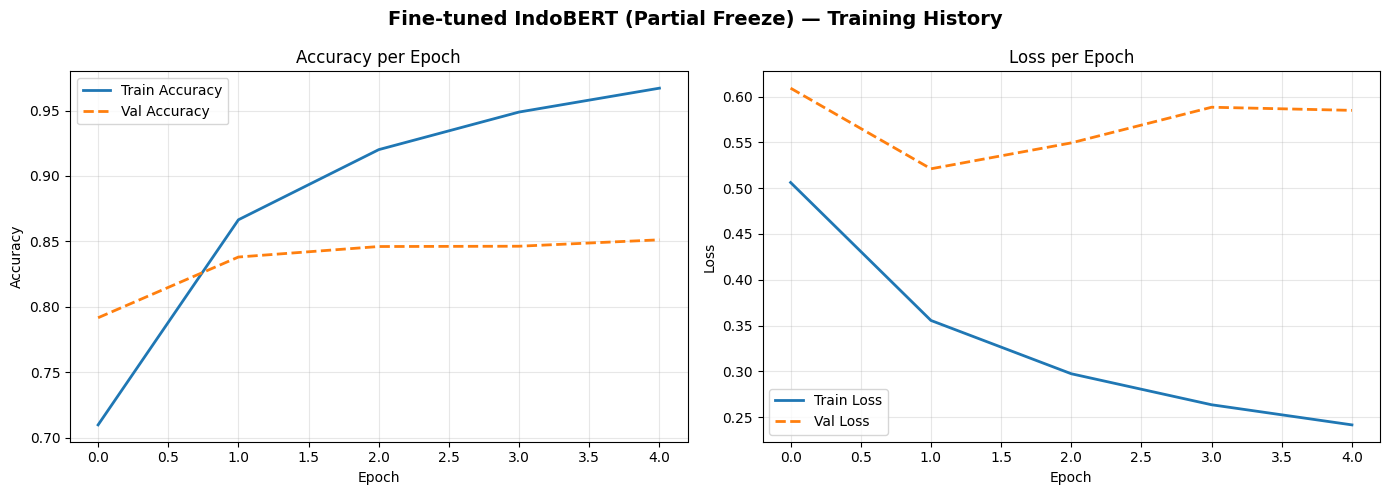

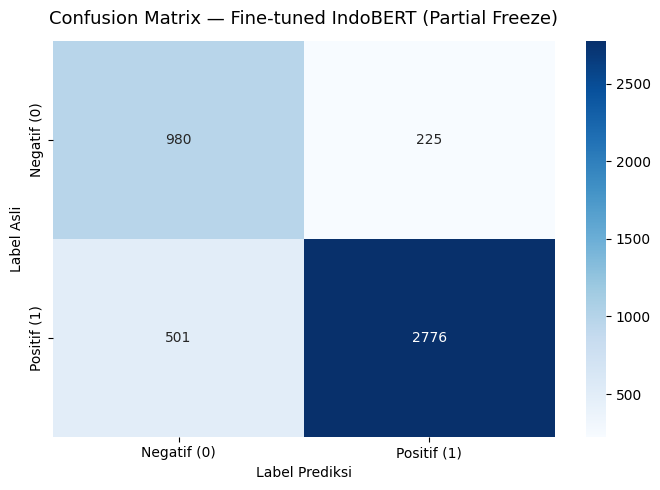

True Negative  (TN): 980
False Positive (FP): 225
False Negative (FN): 501
True Positive  (TP): 2776

 Final Accuracy (threshold=0.55): 83.80%


In [40]:
import torch.serialization

# Load bobot model terbaik
# Set weights_only=False to address UnpicklingError in newer PyTorch versions
checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state'])
best_threshold = checkpoint['threshold']
print(f'✅ Model terbaik dari epoch {checkpoint["epoch"]} dimuat')
print(f'   Val Loss  : {checkpoint["val_loss"]:.4f}')
print(f'   Threshold : {best_threshold:.2f}\n')

_, _, final_preds_raw, final_labels, final_probs = eval_epoch(model, test_loader, criterion, device)

# Terapkan threshold terbaik
final_preds = (np.array(final_probs) >= best_threshold).astype(int)
final_acc   = accuracy_score(final_labels, final_preds)

print('LAPORAN KLASIFIKASI — Fine-tuned IndoBERT (Partial Freeze)')
print('=' * 60)
print(classification_report(
    final_labels, final_preds,
    target_names=['Negatif', 'Positif'],
    digits=4
))

# --- Training History ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fine-tuned IndoBERT (Partial Freeze) — Training History', fontsize=14, fontweight='bold')

axes[0].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0].plot(history['val_acc'],   label='Val Accuracy',   linewidth=2, linestyle='--')
axes[0].set_title('Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[1].plot(history['val_loss'],   label='Val Loss',   linewidth=2, linestyle='--')
axes[1].set_title('Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Confusion Matrix ---
cm = confusion_matrix(final_labels, final_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negatif (0)', 'Positif (1)'],
    yticklabels=['Negatif (0)', 'Positif (1)']
)
plt.title('Confusion Matrix — Fine-tuned IndoBERT (Partial Freeze)', fontsize=13, pad=12)
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (TN): {tn}')
print(f'False Positive (FP): {fp}')
print(f'False Negative (FN): {fn}')
print(f'True Positive  (TP): {tp}')
print(f'\n Final Accuracy (threshold={best_threshold:.2f}): {final_acc * 100:.2f}%')